In [1]:
import sys
print("Python executable:", sys.executable)


Python executable: C:\Users\vamsi\anaconda3\envs\pulmo_ai\python.exe


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    Dropout,
    GlobalAveragePooling2D
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [3]:
train_dir = "dataset/train"
val_dir   = "dataset/val"
test_dir  = "dataset/test"


In [4]:
img_size = (224, 224)
batch_size = 32

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

val_test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

val_data = val_test_gen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

test_data = val_test_gen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)


Found 5588 images belonging to 4 classes.
Found 773 images belonging to 4 classes.
Found 771 images belonging to 4 classes.


In [5]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 222, 222, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 111, 111, 32)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 109, 109, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 54, 54, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 52, 52, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 26, 26, 128)       0

In [6]:
epochs = 15

history = model.fit(
    train_data,
    epochs=epochs,
    validation_data=val_data
)


Epoch 1/15
175/175 [==============================] - 195s 1s/step - loss: 0.9297 - accuracy: 0.6768 - val_loss: 1.7288 - val_accuracy: 0.2561
Epoch 2/15
175/175 [==============================] - 215s 1s/step - loss: 0.8875 - accuracy: 0.6836 - val_loss: 2.1117 - val_accuracy: 0.2432
Epoch 3/15
175/175 [==============================] - 242s 1s/step - loss: 0.8561 - accuracy: 0.6593 - val_loss: 2.0212 - val_accuracy: 0.2574
Epoch 4/15
175/175 [==============================] - 238s 1s/step - loss: 0.7526 - accuracy: 0.7029 - val_loss: 1.8319 - val_accuracy: 0.2846
Epoch 5/15
175/175 [==============================] - 249s 1s/step - loss: 0.7207 - accuracy: 0.7112 - val_loss: 1.5333 - val_accuracy: 0.2885
Epoch 6/15
175/175 [==============================] - 238s 1s/step - loss: 0.6179 - accuracy: 0.7627 - val_loss: 1.2496 - val_accuracy: 0.4631
Epoch 7/15
175/175 [==============================] - 249s 1s/step - loss: 0.5543 - accuracy: 0.7960 - val_loss: 1.1302 - val_accuracy: 0.5006

In [7]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)


25/25 [==============================] - 21s 810ms/step - loss: 0.5330 - accuracy: 0.7795
Test Accuracy: 0.7795071601867676


In [8]:
os.makedirs("model", exist_ok=True)
model.save("model/pulmo_model.h5")


C:\Users\vamsi\anaconda3\envs\pulmo_ai\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


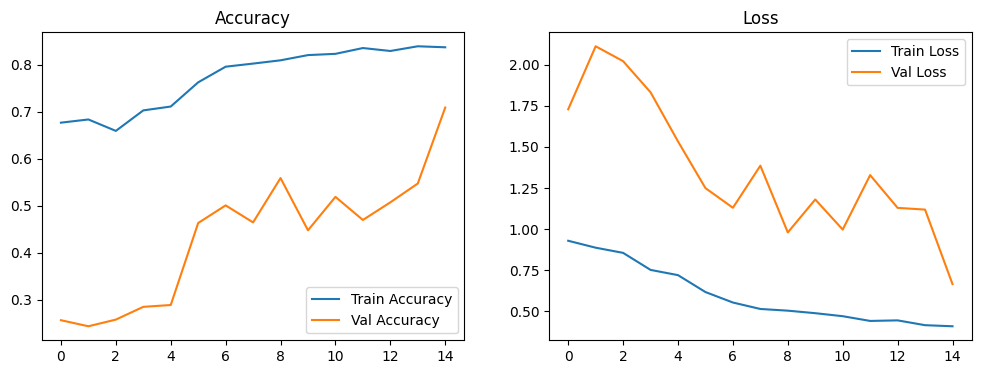

In [9]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')

plt.show()
